In this notebook I try running a training loop with the single-compartment model, using all the channels.
Here I just train the biophysical model's parameters, without any neural ODE augmentation.
We use SSE loss and also try out the interrupted simulation in the end.

In [ ]:
%load_ext autoreload
%autoreload 2


import os
#os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

from jax import config
config.update("jax_enable_x64", True)



import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import optax
from copy import deepcopy


from voltage_fitting.single_build_simulator import (
    get_bounds,
    setup_simulator,
    get_prior,
    get_experimental_data,
    build_cell,
    set_setup,
    transform_uniform_to_normal,
)

from voltage_fitting.posthoc_summary_stats import (
    find_spikes,
    spike_count,
    first_spike_time,
    second_spike_time,
    first_spike_amp,
    second_spike_amp,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
seed = 0
setup = "488683425"
#setup = "485574832"
#setup = "480353286"
#setup = "473601979"
t_max = 199.5
n_particles = 300
steps = 20
lr = 0.001
momentum = 0.0
cost_fn_power = 1.0
cut = 0

all_setup = set_setup(setup)
cell = build_cell(all_setup["capacitance"], all_setup["eleak"], all_setup["gleak"], all_setup["length"])
t, x_o, i_amp = get_experimental_data(setup, cut, t_max)
simulate = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)

x_o = x_o.astype(jnp.float64)

print("Building prior and log likelihood function...")
_, lower, upper = get_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

@jax.jit
def predict(params):
    params_0 = inv_transform_params(params)
    return simulate(params_0, x_o) #[0] # [0] #(number of recordings (1), number of time points) --> (number of time points,)

@jax.jit
def abs_loss(params):
    x, _ = predict(params)
    diff = jnp.nan_to_num((x_o-x[0])**2, nan = 0.0)
    return jnp.sum(diff)

#scaled_loss = get_scaled_loss(x_o, predict, cost_fn_power)
grad_fn = jax.jit(jax.vmap(jax.value_and_grad(abs_loss)))

print("Running Gradient Descent...")

rng_key = jax.random.PRNGKey(seed)
init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1000 initializations randomly.
opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_particles)
)


print(f"opt_params.shape {opt_params.shape}") #(n_particles, lowers.shape)

# 100 * lr is not used because we override the learning rate later at
# `opt_state.hyperparams`.
optimizer = optax.inject_hyperparams(optax.sgd)(
    learning_rate=100 * lr, momentum=momentum
)
opt_state = jax.vmap(optimizer.init)(opt_params)

best_loss_per_chain = 1e10 * jnp.ones((n_particles))#1
best_opt_params_per_chain = opt_params

all_losses_each_chain = []

for epoch in range(steps):
    loss_val, grad_val = grad_fn(opt_params)

    # Save best values per chain.
    condition = loss_val < best_loss_per_chain
    best_loss_per_chain = best_loss_per_chain.at[condition].set(loss_val[condition])
    best_opt_params_per_chain = best_opt_params_per_chain.at[condition].set(
        opt_params[condition]
    )
    all_losses_each_chain.append(deepcopy(best_loss_per_chain))

    grad_norms = jnp.sum(grad_val**2, axis=1) ** 0.5
    print(
        f"Epoch {epoch} Loss: Avg {jnp.nanmean(loss_val)}, Med {jnp.nanmedian(loss_val)}, Min {jnp.nanmin(loss_val)}"
    )

    # Normalize the gradient to (almost exactly) unit length.
    beta = 0.99
    grad_val = (grad_val.T / (grad_norms**beta)).T
    opt_state.hyperparams["learning_rate"] = np.full_like(loss_val, 0.1) #loss_val * lr
    updates, opt_state = jax.vmap(optimizer.update)(grad_val, opt_state)
    opt_params = jax.vmap(optax.apply_updates)(opt_params, updates)


top_10_losses = np.sort(best_loss_per_chain)[:10]
print(f"10 best losses: {top_10_losses}")

# Save.
# filename = f"Single_250312_{setup}_{int(t_max)}_{lr}_{momentum}_{steps}_{cost_fn_power}_{seed}"
# filename = "Single_comp_trial"
# particles = best_opt_params_per_chain
# weights = -best_loss_per_chain

# jnp.savez(f"results/{filename}.npz", particles=particles, weights=weights)

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Building prior and log likelihood function...
Number of parameters: 15
Running Gradient Descent...
opt_params.shape (300, 15)
Epoch 0 Loss: Avg 1056749.4197503494, Med 773690.9148316723, Min 360771.96179451054
Epoch 1 Loss: Avg 974365.6847026008, Med 689933.4361829746, Min 341611.0949203346
Epoch 2 Loss: Avg 919105.8815426121, Med 649373.1553640056, Min 330907.49570792227
Epoch 3 Loss: Avg 886598.0226711709, Med 605785.6763653053, Min 333129.55714440416
Epoch 4 Loss: Avg 855732.0056736796, Med 574819.8505740619, Min 330815.22467866016
Epoch 5 Loss: Avg 857660.8035633324, Med 549992.00423365, Min 332800.0204801774
Epoch 6 Loss: Avg 842286.6932874677, Med 534519.7114283503, Min 329495.5339207834
Epoch 7 Loss: Avg 819169.2081607296, Med 517077.83938385034, Min 331253.50775475457
Epoch 8 Loss: Avg 780715.4434696812, Med 510553.1

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Minimal error: 115.4673
Error in spike_count: 1.0000
Error in first_spike_time: 24.4000
Error in second_spike_time: 1.6500
Error in first_spike_amp: 38.9676
Error in second_spike_amp: 19.3996


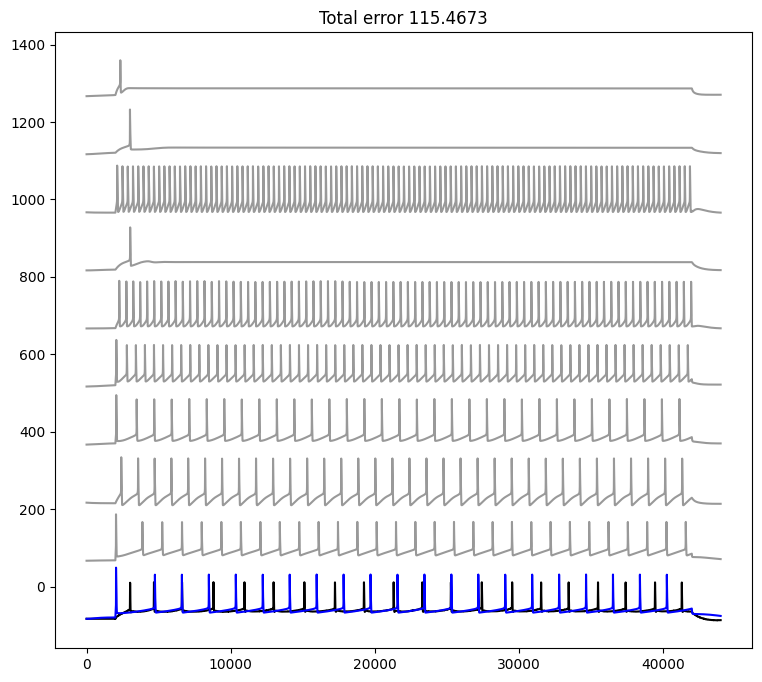

In [14]:
####################################################################################
####################################################################################
################################# POSTHOC ANALYSIS #################################
####################################################################################
####################################################################################

t_max = 1100
all_setup = set_setup(setup)
cell = build_cell(all_setup["capacitance"], all_setup["eleak"], all_setup["gleak"], all_setup["length"])
t, x_o, i_amp = get_experimental_data(setup, cut, t_max)
simulate = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)#*all_setup["length"])

x_o = x_o.astype(jnp.float64)

# transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
# sample_prior = get_prior(lower, upper, transform_params)

@jax.jit
def predict(params):
    params_0 = inv_transform_params(params)
    return simulate(params_0, x_o)[0][0]

vmapped_predict = jax.vmap(predict)
x_pred = vmapped_predict(best_opt_params_per_chain)

if setup == "473601979":
    thr = -30.0
else:
    thr = -20.0  # Default value.

_ = np.random.seed(0)
noise = np.random.randn(len(x_o)) * 1e-2

x_o_spikes = find_spikes(x_o + noise, None, None, thr)
x_o_ss = {
    "spike_count": spike_count(x_o_spikes),
    "first_spike_time": first_spike_time(x_o_spikes),
    "second_spike_time": second_spike_time(x_o_spikes),
    "first_spike_amp": first_spike_amp(x_o, x_o_spikes),
    "second_spike_amp": second_spike_amp(x_o, x_o_spikes),
}

pred_spikes = jax.vmap(find_spikes, in_axes=(0, None, None, None))(
    x_pred, None, None, thr
)
pred_ss = {
    "spike_count": np.asarray([spike_count(p) for p in pred_spikes]),
    "first_spike_time": np.asarray([first_spike_time(p) for p in pred_spikes]),
    "second_spike_time": np.asarray([second_spike_time(p) for p in pred_spikes]),
    "first_spike_amp": np.asarray(
        [first_spike_amp(xp, p) for xp, p in zip(x_pred, pred_spikes)]
    ),
    "second_spike_amp": np.asarray(
        [second_spike_amp(xp, p) for xp, p in zip(x_pred, pred_spikes)]
    ),
}

errors = {}
for key in x_o_ss.keys():
    errors[key] = np.abs(x_o_ss[key] - pred_ss[key])

# Weigh the individusal errors.
summed_errors = (
    np.asarray(errors["spike_count"]).astype(float) * 5.0
    + np.asarray(errors["first_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["second_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["first_spike_amp"]).astype(float) * 1.0
    + np.asarray(errors["second_spike_amp"]).astype(float) * 1.0
)

inds = np.argsort(summed_errors)

print(f"Minimal error: {summed_errors[inds[0]]:.4f}")
print("===========")
for key in errors.keys():
    print(f"Error in {key}: {errors[key][inds[0]]:.4f}")

# Save the single best trace (traces are memory intensive...)
# with open(f"results/pickled_traces/{filename}.pkl", "wb") as handle:
#     pickle.dump(x_pred[inds[0]], handle)

# Save the final samples and errors to easily reconstruct which one was best.
# jnp.savez(
#     f"results/resampled_samples/{filename}.npz",
#     errors=errors,
#     summed_errors=summed_errors,
# )
fig, ax = plt.subplots(1, 1, figsize=(9, 8))
for i, x_plot in enumerate(x_pred[inds[1:10]]):
    _ = ax.plot(x_plot + 150.0 * (i+1), c="gray", alpha=0.8)
_ = ax.plot(x_o, c="k")
_ = ax.plot(x_pred[inds[0]], c="b")
_ = ax.set_title(f"Total error {summed_errors[inds[0]]:.4f}")
# plt.savefig(f"results/pngs/{filename}.png", dpi=200, bbox_inches="tight")
plt.show()

**Let's see how one prediction works - also with interruption**

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


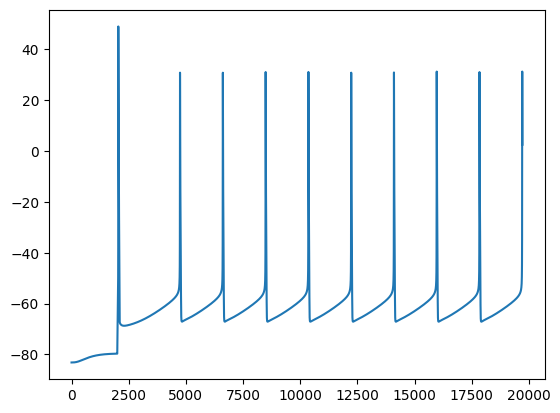

In [16]:
t_max = 1100.0
setup = "488683425"
all_setup = set_setup(setup)
cell = build_cell(all_setup["capacitance"], all_setup["eleak"], all_setup["gleak"], all_setup["length"])
t, x_o, i_amp = get_experimental_data(setup, cut, t_max)
simulate = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)

def predict(params):
    params_0 = inv_transform_params(params)
    return simulate(params_0, x_o, thr=100_000)

v_0, mask = predict(best_opt_params_per_chain[inds[0]])
plt.plot(v_0[0])

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


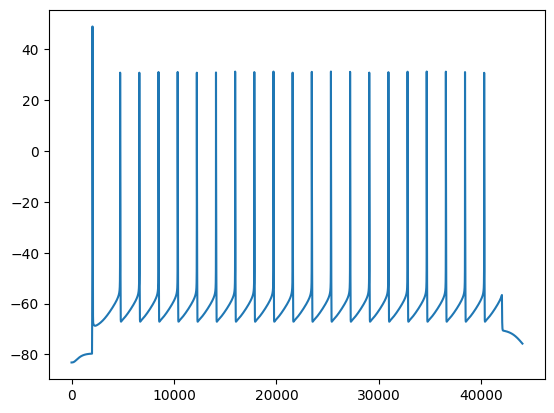

In [15]:
t_max = 1100.0
setup = "488683425"
all_setup = set_setup(setup)
cell = build_cell(all_setup["capacitance"], all_setup["eleak"], all_setup["gleak"], all_setup["length"])
t, x_o, i_amp = get_experimental_data(setup, cut, t_max)
simulate = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)

def predict(params):
    params_0 = inv_transform_params(params)
    return simulate(params_0, x_o, thr=None)

v_1, mask = predict(best_opt_params_per_chain[inds[0]])
plt.plot(v_1[0])